<a href="https://colab.research.google.com/github/kaoru1018/cafe-forecast/blob/main/Cafe%E7%B5%8C%E5%96%B6%E3%83%AC%E3%83%9D%E3%83%BC%E3%83%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Kaoru's Cafe 経営レポート①
#設定 : カフェをオープンしました:coffee:4人掛けテーブル×10、今のところメニューは[コーヒー,ケーキ]のみ:cake:月曜・火曜で各4組のお客様が御来店

import numpy as np
monday_sales=np.array([[4,4],[2,4],[3,3],[4,np.nan]])
tuesday_sales=np.array([[1,2],[6,6],[2,3],[np.nan,2]])
all_sales=np.vstack((monday_sales,tuesday_sales))

clean_sales=np.nan_to_num(all_sales,nan=0)
safe_sales=np.clip(clean_sales,0,50)

avg_sales=np.mean(safe_sales,axis=0,keepdims=True)
diff_from_avg=safe_sales - avg_sales

best_order_idx=np.argmax(safe_sales[:,0])

trend=np.sign(diff_from_avg)

print("---  Kaoru's Cafe 経営レポート① ---")
print(f"1. 整理された売上データ:\n{safe_sales}")
print(f"2. コーヒーが最も売れたのは {best_order_idx} 番目の注文です！")
print(f"3. 売上トレンド (1=絶好調, -1=要対策):\n{trend}")

---  Kaoru's Cafe 経営レポート① ---
1. 整理された売上データ:
[[4. 4.]
 [2. 4.]
 [3. 3.]
 [4. 0.]
 [1. 2.]
 [6. 6.]
 [2. 3.]
 [0. 2.]]
2. コーヒーが最も売れたのは 5 番目の注文です！
3. 売上トレンド (1=絶好調, -1=要対策):
[[ 1.  1.]
 [-1.  1.]
 [ 1.  0.]
 [ 1. -1.]
 [-1. -1.]
 [ 1.  1.]
 [-1.  0.]
 [-1. -1.]]


In [ ]:
#Kaoru's Cafe 経営レポート②
#設定 : 売り上げを知りたいから、値段を追加した(コーヒー500円,ケーキ800円)

import numpy as np
prices = np.array([500, 800])

# 【5&6を合体】「個数」と「単価」をガッチャンコして、注文ごとの合計を出す
# np.dot を使うと「掛けて足す」を一行でやってくれます
order_totals = np.dot(safe_sales, prices)

# 【7】全売上の合計
total_revenue = np.sum(order_totals)

# 【8】商品別の売上合計（これは分析に必要なので残します！）
item_totals = np.sum(safe_sales * prices, axis=0)

print("\n--- 💰 Kaoru's Cafe 収益レポート② ---")
print(f"5. 各注文の合計請求額: {order_totals} 円")
print(f"6. 本日の総売上: {total_revenue:,.0f} 円")
print(f"7. 商品別売上合計 [コーヒー, ケーキ]: {item_totals} 円")


--- 💰 Kaoru's Cafe 収益レポート② ---
5. 各注文の合計請求額: [5200. 4200. 3900. 2000. 2100. 7800. 3400. 1600.] 円
6. 本日の総売上: 30,200 円
7. 商品別売上合計 [コーヒー, ケーキ]: [11000. 19200.] 円


In [ ]:
#Kaoru's Cafe 経営レポート③
#設定 : 「売上はあるけど、接客にムラはないか？」「お得意様は誰か？」を分析します。

import numpy as np

# 1. 【仕入れ】月曜と火曜のオーダー伝票（[コーヒー, ケーキ]の個数）
monday_sales = np.array([[4,4],[2,4],[3,3],[4,np.nan]])
tuesday_sales = np.array([[1,2],[6,6],[2,3],[np.nan,2]])

# 2. 【合体】2日分のデータを縦に積み上げて「週報」の形にする
all_sales = np.vstack((monday_sales, tuesday_sales))

# 3. 【清掃】入力漏れ(NaN)を「0」に置き換えて、計算エラーを防ぐ
# ※ safe_salesとして以降で使用
safe_sales = np.nan_to_num(all_sales, nan=1)

# 4. 【設定】メニューの単価表を作成 (追加)
prices = np.array([500, 800])

# 5. 【一括計算】「注文ごとの合計」を出す（行列の掛け算：内積） (追加)
order_totals = np.dot(safe_sales, prices)

# --- 1. 未攻略コード：np.where で「お得意様」を判定 ---
# 1組あたりの合計請求額(order_totals)が 5,000円 を超えたら「VIP」、そうでなければ「通常」
# np.where(条件, 真の場合, 偽の場合)
customer_status = np.where(order_totals > 5000, "VIP", "Standard")

# --- 2. 未攻略コード：np.any / np.all で「異常」をチェック ---
# 1組で10個以上注文した「爆買い」の組があるか？
is_huge_order = np.any(safe_sales >= 10)
# 全組が最低1つはコーヒーを頼んでいるか？
all_drank_coffee = np.all(safe_sales[:, 0] >= 1)

# --- 3. 未攻略コード：np.std で「注文のバラツキ」を調査 ---
# 客数によって注文数に激しい差（ムラ）がないかを確認
# 標準偏差(std)が大きいほど、仕込みが難しい「予測しづらい店」ということ
sales_std = np.std(safe_sales, axis=0)

# --- 4. 未攻略コード：np.unique で「注文パターンの種類」を見る ---
# どんな個数の組み合わせがよく出るか、ユニークな値を取り出す
unique_patterns = np.unique(safe_sales, axis=0)

print("--- 📈 Kaoru's Cafe 経営レポート③ ---")
print(f"1. お客様ランク: {customer_status}")
print(f"2. 10個以上の大量注文はある？: {'はい' if is_huge_order else 'いいえ'}")
print(f"3. 注文のバラツキ [コーヒー, ケーキ]: {sales_std}")
print(f"4. 本日のユニークな注文パターン:\n{unique_patterns}")

--- 📈 Kaoru's Cafe 経営レポート③ ---
1. お客様ランク: ['VIP' 'Standard' 'Standard' 'Standard' 'Standard' 'VIP' 'Standard'
 'Standard']
2. 10個以上の大量注文はある？: いいえ
3. 注文のバラツキ [コーヒー, ケーキ]: [1.615356   1.45236875]
4. 本日のユニークな注文パターン:
[[1. 2.]
 [2. 3.]
 [2. 4.]
 [3. 3.]
 [4. 1.]
 [4. 4.]
 [6. 6.]]


In [ ]:
#Kaoru's Cafe 経営レポート④
#設定 : 今あるメニューをもう少し美味しくしたい！
#材料にこだわると原価は上がってしまう...でも利益もあまり減らしたくない
#単に「美味しくする」だけでなく、「どこまでこだわってもお店がつぶれないか」の境界線をNumpyに教えてもらおう!

import numpy as np
import pandas as pd

items=['コーヒー','ケーキ']
prices=np.array([500,800])
current_costs=np.array([100,200])

new_costs=current_costs*1.5

current_profits=prices-current_costs
new_profits=prices-new_costs

current_margins=current_profits/prices*100
new_margins=new_profits/prices*100

profit_diff=current_profits-new_profits

report_data={
    '商品名':items,
    '現状利益率(%)':current_margins,
    '改善後利益率(%)':new_margins,
    '利益減少額(円)': profit_diff
}

df=pd.DataFrame(report_data)
df.set_index('商品名',inplace=True)

print("---☕Kaoru's Cafe 経営改善レポート④---")
print(df.round(1))

print("\n--- 💡 kaoru店長の分析メモ ---")
bad_margin_items = df[df['改善後利益率(%)'] < 65]
if not bad_margin_items.empty:
    print(f"⚠️ 利益率が65%を下回る商品があります：{', '.join(bad_margin_items.index)}")


---☕Kaoru's Cafe 経営改善レポート④---
      現状利益率(%)  改善後利益率(%)  利益減少額(円)
商品名                                
コーヒー      80.0       70.0      50.0
ケーキ       75.0       62.5     100.0

--- 💡 kaoru店長の分析メモ ---
⚠️ 利益率が65%を下回る商品があります：ケーキ


In [ ]:
#Kaoru's Cafe 経営レポート⑤
#設定 : ケーキを50円値上げして、原価を1.5倍にする!

import numpy as np
import pandas as pd

items=['コーヒー','ケーキ']
prices=np.array([500,850])#ケーキを50円値上げした
current_costs=np.array([100,200])

new_costs=current_costs*1.5

new_profits=prices-new_costs
new_margins=(new_profits/prices)*100

report_data={
    '商品名':items,
    '販売価格': prices,
    '新しい原価': new_costs,
    '改善後利益率(%)': new_margins,
}

df=pd.DataFrame(report_data)
df.set_index('商品名',inplace=True)

df_sorted=df.sort_values(by='改善後利益率(%)',ascending=False)
print("---☕Kaoru's Cafe 経営改善レポート⑤---")
print('💰50円値上げ後のレポート')
print(df_sorted.round(1))

print('---決断チェック---')
cake_margin=df.loc['ケーキ','改善後利益率(%)']
if cake_margin >= 64:
    print(f'✅ケーキの利益率は{cake_margin:.1f}%まで回復！')
    print('これなら『美味しさ』と『経営』の両立ができそうです。')
else:
    print(f'50円値上げしても利益率は{cake_margin:.1f}%です。もう少し工夫が必要かも？')

---☕Kaoru's Cafe 経営改善レポート⑤---
💰50円値上げ後のレポート
      販売価格  新しい原価  改善後利益率(%)
商品名                         
コーヒー   500  150.0       70.0
ケーキ    850  300.0       64.7
---決断チェック---
✅ケーキの利益率は64.7%まで回復！
これなら『美味しさ』と『経営』の両立ができそうです。


In [ ]:
#Kaoru's Cafe 経営レポート⑥
#設定 : 新作のケーキの売り上げも好調なので、メニューを増やすことにしたよ!

import numpy as np
import pandas as pd

items=['コーヒー','紅茶','ケーキ','トースト']
prices=np.array([500,450,850,600])
current_costs=np.array([100,80,200,150])

new_costs=current_costs*1.5

new_profits=prices-new_costs
new_margins=(new_profits/prices)*100

report_data={
    '商品名':items,
    'カテゴリー':['飲み物','飲み物','食べ物','食べ物'],
    '販売価格': prices,
    '改善後利益率(%)': new_margins,
}

df=pd.DataFrame(report_data)
df.set_index('商品名',inplace=True)

df_sorted=df.sort_values(by='改善後利益率(%)',ascending=False)
print("---☕Kaoru's Cafe 経営改善レポート⑥---")
print('メニュー拡大版レポート')
print(df_sorted.round(1))

print('\n---🍞食べ物メニューの状況---')
food_only=df[df['カテゴリー']=='食べ物']
print(food_only.round(1))

---☕Kaoru's Cafe 経営改善レポート⑥---
メニュー拡大版レポート
     カテゴリー  販売価格  改善後利益率(%)
商品名                        
紅茶     飲み物   450       73.3
コーヒー   飲み物   500       70.0
ケーキ    食べ物   850       64.7
トースト   食べ物   600       62.5

---🍞食べ物メニューの状況---
     カテゴリー  販売価格  改善後利益率(%)
商品名                        
ケーキ    食べ物   850       64.7
トースト   食べ物   600       62.5


In [ ]:
#Kaoru's Cafe 経営レポート⑦
#設定 : 新作のパフェをメニューに追加するよ!
#あと、600円以下の商品（利益が低そうなもの）をピンポイントで1.1倍にしてみよう！

import numpy as np
import pandas as pd

# 既存の価格（コーヒー, 紅茶, ケーキ, トースト）
old_prices = np.array([500, 450, 850, 650])

# 1. 【新兵器：np.append】 新メニュー「スペシャルパフェ(1200円)」を追加！
new_item_price = np.array([1200])
all_prices = np.append(old_prices, new_item_price)

# 3. 【新兵器：np.where】 利益率が低い商品だけ「10%値上げ」するシミュレーション
# 600円以下の商品（利益が低そうなもの）をピンポイントで1.1倍に！
sim_prices = np.where(all_prices <= 600, all_prices * 1.1, all_prices)

print("--- ---☕Kaoru's Cafe 経営改善レポート⑦---")
print("価格シミュレーション")
print(f"新メニュー追加後の全価格: {all_prices}")
print(f"条件付き値上げ後の価格: {sim_prices.round(0)}")

--- ---☕Kaoru's Cafe 経営改善レポート⑦---
価格シミュレーション
新メニュー追加後の全価格: [ 500  450  850  650 1200]
条件付き値上げ後の価格: [ 550.  495.  850.  650. 1200.]


In [ ]:
#Kaoru's Cafe 経営レポート⑧
#設定 : 1週間（7日間）の売上データを作って、どの日に売上が偏っているか、平均してどれくらい売れているかを分析してみることにした!

import numpy as np
import pandas as pd

# メニュー名（前回追加したパフェを含む5品）
items = ['コーヒー', '紅茶', 'ケーキ', 'トースト', 'パフェ']

# 1. 【新兵器：np.random.randint】 1週間の売上個数をランダムに生成
# 1日あたり「5個〜30個」の間で、5商品×7日分のデータを作る
np.random.seed(42) # 数字を固定するためのおまじない
sales_data = np.random.randint(5, 30, size=(5, 7))

# 2. 【新兵器：np.sum(axis=1)】 商品ごとの「1週間合計」を計算
item_totals = np.sum(sales_data, axis=1)

# 3. 【新兵器：np.mean】 1日あたりの「平均売上個数」を計算
daily_average = np.mean(sales_data)

# 4. 【新兵器：np.max / np.min】 1週間での「最高販売数」と「最低販売数」
max_sales = np.max(sales_data)
min_sales = np.min(sales_data)

# --- 結果の表示 ---
print("--- 📊 Kaoru's Cafe 1週間の売上分析⑧ ---")
print(f"全商品の1週間合計販売数: {item_totals}")
print(f"店全体の1日平均販売数: {daily_average:.1f} 個")
print(f"今週の最高販売数: {max_sales} 個 / 最低販売数: {min_sales} 個")

# 表形式にして見やすくします
df_weekly = pd.DataFrame(sales_data, index=items,
                         columns=['月', '火', '水', '木', '金', '土', '日'])
print("\n【1週間の売上推移表】")
print(df_weekly)

--- 📊 Kaoru's Cafe 1週間の売上分析⑧ ---
全商品の1週間合計販売数: [117 141 132 104 138]
店全体の1日平均販売数: 18.1 個
今週の最高販売数: 29 個 / 最低販売数: 5 個

【1週間の売上推移表】
       月   火   水   木   金   土   日
コーヒー  11  24  19  15  12  25  11
紅茶    23  27  15  15  28  25   8
ケーキ   12  28   7  26  25   6  28
トースト  16  10   6  25   5  16  26
パフェ   16  29  21  14  20  19  19


--- 🌸 Kaoru's Cafe お花見在庫レポート⑨ ---
      予想販売数  累計販売数  前日比増減  推奨予備数
3/28     20     20      0      4
3/29     24     44      4      4
3/30     30     74      6      5
3/31     45    119     15      6
4/1      55    174     10      7
4/2      60    234      5      7
4/3      50    284    -10      7


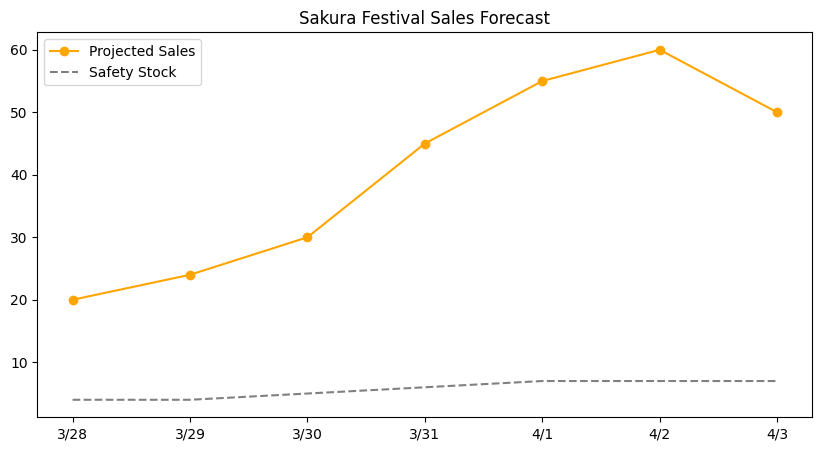

In [ ]:
#Kaoru's Cafe 経営レポート⑨
#設定 : 今週末はお花見日和:cherry_blossom:『3/28からのお花見期間における、動的在庫管理モデル』をつくってみた。
#単なる予測だけでなく、累積（cumsum）で全体量を把握し、差分（diff）でトレンドの変化を捉え、
#さらに平方根（sqrt）を用いて安全在庫を算出することで、欠品による機会損失（チャンスロス）を防ぐためのシミュレーションです!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # グラフ用に追加

# お花見期間（3/28〜4/3）のケーキ予想販売数
# 桜の開花に合わせて後半にかけて増えていく予想
daily_sales = np.array([20, 24, 30, 45, 55, 60, 50])
# 期間中の「累計」販売数
# これで「合計で何個作ったか」がわかります
total_production = np.cumsum(daily_sales)
# 前日との「売上の差」
# どのタイミングで急激に忙しくなるか（伸び率）をチェック！
sales_growth = np.diff(daily_sales, prepend=20) #3/28の前を20として比較
# 売上の「バラつき」を考慮した予備在庫の計算
# 統計的に、標準偏差のルートなどで安全在庫を計算するイメージ
safety_stock = np.sqrt(daily_sales).astype(int)
# --- レポート表示 ---
days = ['3/28', '3/29', '3/30', '3/31', '4/1', '4/2', '4/3']

# 表の作成（Pandas）
# ここで「df_sakura」という名前の器にデータを入れます
df_sakura = pd.DataFrame({
    '予想販売数': daily_sales,
    '累計販売数': total_production,
    '前日比増減': sales_growth,
    '推奨予備数': safety_stock
}, index=days)

# 結果の表示
print(f"--- 🌸 Kaoru's Cafe お花見在庫レポート⑨ ---")
print(df_sakura)

# グラフ用の横軸（3/28を1日目として、7日分）
x = np.linspace(1, 7, 7)
# グラフを描く
plt.figure(figsize=(10, 5))
plt.plot(days, daily_sales, marker='o', label='Projected Sales', color='orange')
plt.plot(days, safety_stock, '--', label='Safety Stock', color='gray')

plt.title("Sakura Festival Sales Forecast")
plt.legend()
plt.show()